<div align="center">
  <h1>Analítica de Datos para Negocios Digitales</h1>
  <h2>Análisis Exploratorio de Datos (EDA)</h2>
  <h3>IKAL - "Alma Artesanal"</h3>
</div>

<br>


**Elaborado por el Equipo de Trabajo IKAL:**
* María Del Rosario Maldonado Hilario - 230438
* María de los Ángeles García Cortez - 230538
* Karla Yulenni Dominguez Amador - 230284

**Grado / Grupo:** 9° "A"

**Docente:** M.T.I. Marco A. Ramírez

# 1. Propósito del Análisis Exploratorio de Datos

El presente Análisis Exploratorio de Datos (EDA) tiene como propósito conocer, describir y comprender el comportamiento de los datos comerciales y operativos de IKAL "Alma Artesanal".

El análisis permitirá:

1. Evaluar la calidad, consistencia e integridad de los datos.
2. Identificar valores nulos, duplicados y datos atípicos.
3. Analizar la distribución de las principales variables.
4. Identificar relaciones entre variables comerciales.
5. Detectar patrones temporales y geográficos.
6. Responder preguntas de negocio mediante evidencia cuantitativa.
7. Generar hallazgos que puedan apoyar la toma de decisiones.

Cada gráfica principal se interpreta respondiendo cuatro preguntas: **qué se observa**, **qué significa**, **qué posible causa lo explica** y **qué decisión podría tomarse**, evitando afirmar relaciones de causalidad que los datos por sí solos no pueden probar.

**2. Importamos las librerías de Python para manipular, analizar y graficar datos**

Utilizaremos `pandas` para la manipulación estructural de los datos, `numpy` para cálculos numéricos, `matplotlib` y `seaborn` para las visualizaciones estadísticas, y `folium` para los mapas interactivos.

In [59]:
# Si folium no está instalado en tu entorno, descomenta la siguiente línea:
!pip install folium

In [60]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from IPython.display import display

# Configuración visual y de Pandas
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# 2. Carga y exploración inicial de los datasets

Se trabajará con cuatro fuentes de información principales:

- **artesanos:** información relacionada con los productores.
- **compradores:** información relacionada con los clientes.
- **productos:** catálogo de productos.
- **ventas:** registros de las transacciones realizadas.

Antes de realizar el análisis se verifica la estructura y dimensión de cada dataset.

In [61]:
# Carga de datasets
artesanos = pd.read_csv("artesanos.csv")
compradores = pd.read_csv("compradores.csv")
productos = pd.read_csv("productos.csv")
ventas = pd.read_csv("ventas.csv")

print("Dimensiones de los datasets:")
for nombre, df in [("Artesanos", artesanos), ("Compradores", compradores),
                    ("Productos", productos), ("Ventas", ventas)]:
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")

Dimensiones de los datasets:
  Artesanos: 60 filas x 8 columnas
  Compradores: 900 filas x 6 columnas
  Productos: 150 filas x 10 columnas
  Ventas: 3614 filas x 11 columnas


In [62]:
# Conversión de fechas
ventas['fecha_venta'] = pd.to_datetime(ventas['fecha_venta'])
artesanos['fecha_registro'] = pd.to_datetime(artesanos['fecha_registro'])
compradores['fecha_registro'] = pd.to_datetime(compradores['fecha_registro'])

# Variables temporales derivadas
ventas['año_venta'] = ventas['fecha_venta'].dt.year
ventas['mes'] = ventas['fecha_venta'].dt.month
ventas['nombre_mes'] = ventas['fecha_venta'].dt.month_name()
ventas['mes_año'] = ventas['fecha_venta'].dt.to_period('M').astype(str)

# Ordenar explícitamente evita que las gráficas queden en orden alfabético,
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_es = {'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
           'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'}

ventas['dia_semana'] = ventas['fecha_venta'].dt.day_name()
ventas['dia_semana_es'] = pd.Categorical(
    ventas['dia_semana'].map(dias_es),
    categories=[dias_es[d] for d in orden_dias], ordered=True
)

ventas.head()

,venta_id,producto_id,comprador_id,ubicacion_comprador,fecha_venta,cantidad,metodo_pago,total,tipo_producto,canal,estatus,año_venta,mes,nombre_mes,mes_año,dia_semana,dia_semana_es
0,1,10,1,CDMX,2023-08-30,1,Crédito,979.72,Marca IKAL,Facebook,Entregado,2023,8,August,2023-08,Wednesday,Miércoles
1,2,10,1,CDMX,2023-09-06,1,Crédito,979.72,Marca IKAL,Web,Entregado,2023,9,September,2023-09,Wednesday,Miércoles
2,3,10,1,CDMX,2023-09-08,1,Crédito,979.72,Marca IKAL,WhatsApp,Entregado,2023,9,September,2023-09,Friday,Viernes
3,4,10,2,Toluca,2023-09-09,1,Débito,979.72,Marca IKAL,Web,Entregado,2023,9,September,2023-09,Saturday,Sábado
4,5,10,2,Toluca,2023-09-10,1,Débito,979.72,Marca IKAL,Facebook,Entregado,2023,9,September,2023-09,Sunday,Domingo


# 3. Análisis de Calidad de los Datos e Integridad Referencial

Antes de graficar, se ejecuta una revisión de calidad completa: valores nulos, registros duplicados, **integridad referencial** (que los IDs relacionados entre tablas existan realmente), **consistencia** (categorías válidas, valores fuera de rango, coherencia entre tablas) y **cobertura temporal** (periodo real cubierto por los datos).

In [63]:
# 3.1 Nulos, duplicados y dimensiones por dataset
datasets = {"Artesanos": artesanos, "Compradores": compradores, "Productos": productos, "Ventas": ventas}

resumen_calidad = pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Filas": [df.shape[0] for df in datasets.values()],
    "Columnas": [df.shape[1] for df in datasets.values()],
    "Nulos": [df.isnull().sum().sum() for df in datasets.values()],
    "Duplicados": [df.duplicated().sum() for df in datasets.values()]
})
display(resumen_calidad)

,Dataset,Filas,Columnas,Nulos,Duplicados
0,Artesanos,60,8,0,0
1,Compradores,900,6,0,0
2,Productos,150,10,0,0
3,Ventas,3614,17,0,0


In [64]:
# 3.2 Cobertura temporal (se calcula Y se muestra explícitamente)
inicio = ventas["fecha_venta"].min()
fin = ventas["fecha_venta"].max()
dias_cubiertos = (fin - inicio).days

print(f"Cobertura temporal del dataset de ventas:")
print(f"  Fecha más antigua : {inicio.date()}")
print(f"  Fecha más reciente: {fin.date()}")
print(f"  Días cubiertos    : {dias_cubiertos} (~{dias_cubiertos/365:.1f} años)")
print()
print("Registros de venta por año:")
print(ventas['año_venta'].value_counts().sort_index())

Cobertura temporal del dataset de ventas:
  Fecha más antigua : 2023-08-30
  Fecha más reciente: 2026-08-10
  Días cubiertos    : 1076 (~2.9 años)

Registros de venta por año:
año_venta
2023      67
2024     874
2025    1658
2026    1015
Name: count, dtype: int64


**Nota sobre cobertura temporal:** los datos cubren de agosto de 2023 a agosto de 2026. **2023 y 2026 son años parciales** (2023 solo tiene 5 meses de datos; 2026 solo llega hasta agosto), por lo que cualquier comparación de ingresos totales entre años debe normalizarse (por ejemplo, promedio mensual).

In [65]:
# 3.3 Integridad referencial: ¿los IDs relacionados entre tablas existen realmente?

# a) Todo producto_id vendido debe existir en el catálogo de productos
prod_huerfanos = set(ventas['producto_id'].unique()) - set(productos['producto_id'].unique())

# b) Todo comprador_id en ventas debe existir en el catálogo de compradores
comp_huerfanos = set(ventas['comprador_id'].unique()) - set(compradores['comprador_id'].unique())

# c) Todo artesano_id referenciado en productos (distinto de 0 = "Marca IKAL") debe existir en artesanos
art_huerfanos = (set(productos.loc[productos['artesano_id'] != 0, 'artesano_id'].unique())
                  - set(artesanos['artesano_id'].unique()))

integridad = pd.DataFrame({
    "Relación": ["ventas.producto_id -> productos.producto_id",
                 "ventas.comprador_id -> compradores.comprador_id",
                 "productos.artesano_id -> artesanos.artesano_id"],
    "IDs huérfanos": [len(prod_huerfanos), len(comp_huerfanos), len(art_huerfanos)]
})
display(integridad)

,Relación,IDs huérfanos
0,ventas.producto_id -> productos.producto_id,0
1,ventas.comprador_id -> compradores.comprador_id,0
2,productos.artesano_id -> artesanos.artesano_id,0


In [66]:
# 3.4 Consistencia: categorías válidas y coherencia entre tablas

print("Valores únicos por columna categórica en 'ventas':")
for col in ['canal', 'metodo_pago', 'tipo_producto', 'estatus']:
    print(f"  {col}: {sorted(ventas[col].unique())}")

# ¿El tipo_producto registrado en ventas coincide con el tipo del catálogo de productos?
cruce_tipo = ventas.merge(productos[['producto_id', 'tipo']], on='producto_id', how='left')
inconsistencias_tipo = (cruce_tipo['tipo_producto'] != cruce_tipo['tipo']).sum()
print(f"\nVentas con tipo_producto inconsistente respecto al catálogo: {inconsistencias_tipo}")

# ¿Existen montos o cantidades fuera de rango lógico (negativos o cero)?
montos_invalidos = (ventas['total'] <= 0).sum()
cantidades_invalidas = (ventas['cantidad'] <= 0).sum()
print(f"Ventas con 'total' <= 0: {montos_invalidos}")
print(f"Ventas con 'cantidad' <= 0: {cantidades_invalidas}")

# ¿Hay ventas registradas ANTES de que el comprador se haya registrado? (inconsistencia lógica)
cruce_fecha = ventas.merge(compradores[['comprador_id', 'fecha_registro']], on='comprador_id', how='left')
ventas_antes_registro = (cruce_fecha['fecha_venta'] < cruce_fecha['fecha_registro']).sum()
print(f"Ventas con fecha anterior al registro del comprador: {ventas_antes_registro}")

# Distribución del estatus del pedido
print("\nDistribución de 'estatus' en ventas:")
display(ventas['estatus'].value_counts().to_frame("Frecuencia"))
pct_cancelado = (ventas['estatus'] == 'Cancelado').mean() * 100
print(f"% de pedidos cancelados: {pct_cancelado:.2f}%")

Valores únicos por columna categórica en 'ventas':
  canal: ['Facebook', 'Instagram', 'Web', 'WhatsApp']
  metodo_pago: ['Crédito', 'Débito']
  tipo_producto: ['Artesano', 'Marca IKAL']
  estatus: ['Cancelado', 'En preparación', 'Entregado', 'Enviado']

Ventas con tipo_producto inconsistente respecto al catálogo: 0
Ventas con 'total' <= 0: 0
Ventas con 'cantidad' <= 0: 0
Ventas con fecha anterior al registro del comprador: 0

Distribución de 'estatus' en ventas:


,Frecuencia
estatus,
Entregado,2597
Enviado,482
En preparación,294
Cancelado,241


% de pedidos cancelados: 6.67%


### Nota — Hallazgos de calidad e integridad

* **Nulos y duplicados:** no se identificaron valores nulos ni registros duplicados en ninguno de los cuatro datasets. Esto permite trabajar con los datos originales sin necesidad de imputación ni limpieza adicional.
* **Integridad referencial:** se confirma con evidencia (no solo se asume) que **no existen IDs huérfanos**: todo producto, comprador y artesano referenciado en las tablas relacionadas existe en su catálogo correspondiente. Tampoco hay inconsistencias entre `tipo_producto` (tabla ventas) y `tipo` (catálogo de productos), ni ventas registradas antes de la fecha de alta del comprador, ni montos o cantidades fuera de rango lógico.
* **Consistencia — hallazgo importante:** el **6.67% de los pedidos (241 de 3,614) tiene estatus "Cancelado"**. 
  * **Decisión tomada:** a partir de este punto, todos los indicadores financieros (ingresos, ticket promedio, comparativas por canal, mapas, etc.) se calculan sobre `ventas_validas`, es decir, **excluyendo los pedidos cancelados**, ya que un pedido cancelado no representa un ingreso real para el negocio. Los pedidos cancelados sí se conservan para análisis operativos (por ejemplo, tasa de cancelación por canal), que quedan como línea de trabajo futura.
* **Cobertura temporal:** el dataset cubre del 2023-08-30 al 2026-08-10. 2023 y 2026 son años incompletos.

In [67]:
# para que los indicadores de ingresos reflejen ventas efectivamente concretadas.
ventas_validas = ventas[ventas['estatus'] != 'Cancelado'].copy()

print(f"Ventas totales registradas : {len(ventas):,}")
print(f"Ventas válidas (no canceladas): {len(ventas_validas):,}")
print(f"Ingreso total (con cancelados)   : ${ventas['total'].sum():,.2f} MXN")
print(f"Ingreso total (sin cancelados)   : ${ventas_validas['total'].sum():,.2f} MXN")

Ventas totales registradas : 3,614
Ventas válidas (no canceladas): 3,373
Ingreso total (con cancelados)   : $2,588,255.55 MXN
Ingreso total (sin cancelados)   : $2,411,947.83 MXN


# 4. Análisis Univariado y Detección de Datos Atípicos (Outliers)

Se generan las estadísticas descriptivas completas (incluyendo varianza) para conocer la dispersión de las ventas, se revisan las frecuencias de las variables categóricas, y se detectan outliers de forma **cuantitativa** (método IQR) en vez de solo describirlos visualmente.

In [68]:
# 4.1 Medidas estadísticas para variables numéricas (sobre ventas válidas)
estadisticas = pd.DataFrame({
    "Media": ventas_validas[["cantidad", "total"]].mean(),
    "Mediana": ventas_validas[["cantidad", "total"]].median(),
    "Moda": ventas_validas[["cantidad", "total"]].mode().iloc[0],
    "Mínimo": ventas_validas[["cantidad", "total"]].min(),
    "Máximo": ventas_validas[["cantidad", "total"]].max(),
    "Varianza": ventas_validas[["cantidad", "total"]].var(),
    "Desv. Estándar": ventas_validas[["cantidad", "total"]].std(),
    "P25": ventas_validas[["cantidad", "total"]].quantile(0.25),
    "P75": ventas_validas[["cantidad", "total"]].quantile(0.75),
})
display(estadisticas.round(2))

,Media,Mediana,Moda,Mínimo,Máximo,Varianza,Desv. Estándar,P25,P75
cantidad,1.15,1.00,1.00,1.00,2.00,0.13,0.36,1.00,1.00
total,715.07,648.37,299.41,126.79,"2,781.98","211,561.46",459.96,312.51,947.07


In [69]:
# 4.2 Frecuencias de variables categóricas
for col, titulo in [("canal", "Canal de venta"), ("metodo_pago", "Método de pago"),
                     ("tipo_producto", "Tipo de producto")]:
    freq = ventas_validas[col].value_counts().to_frame("Frecuencia")
    freq["% del total"] = (freq["Frecuencia"] / freq["Frecuencia"].sum() * 100).round(2)
    print(f"--- {titulo} ---")
    display(freq)

--- Canal de venta ---


,Frecuencia,% del total
canal,,
Web,1374,40.74
Instagram,965,28.61
Facebook,689,20.43
WhatsApp,345,10.23


--- Método de pago ---


,Frecuencia,% del total
metodo_pago,,
Débito,1698,50.34
Crédito,1675,49.66


--- Tipo de producto ---


,Frecuencia,% del total
tipo_producto,,
Artesano,2288,67.83
Marca IKAL,1085,32.17


In [70]:
# 4.3 Detección cuantitativa de outliers en 'total' (método IQR)
q1 = ventas_validas["total"].quantile(0.25)
q3 = ventas_validas["total"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q1 + 1.5 * iqr if False else q3 + 1.5 * iqr

outliers = ventas_validas[(ventas_validas["total"] < limite_inferior) | (ventas_validas["total"] > limite_superior)]

print(f"Q1 = {q1:.2f}  |  Q3 = {q3:.2f}  |  IQR = {iqr:.2f}")
print(f"Límite inferior = {limite_inferior:.2f}  |  Límite superior = {limite_superior:.2f}")
print(f"Outliers detectados: {len(outliers)} de {len(ventas_validas)} ventas ({len(outliers)/len(ventas_validas)*100:.2f}%)")
print(f"Rango de montos atípicos: ${outliers['total'].min():,.2f} - ${outliers['total'].max():,.2f} MXN")

Q1 = 312.51  |  Q3 = 947.07  |  IQR = 634.56
Límite inferior = -639.33  |  Límite superior = 1898.91
Outliers detectados: 92 de 3373 ventas (2.73%)
Rango de montos atípicos: $1,959.44 - $2,781.98 MXN


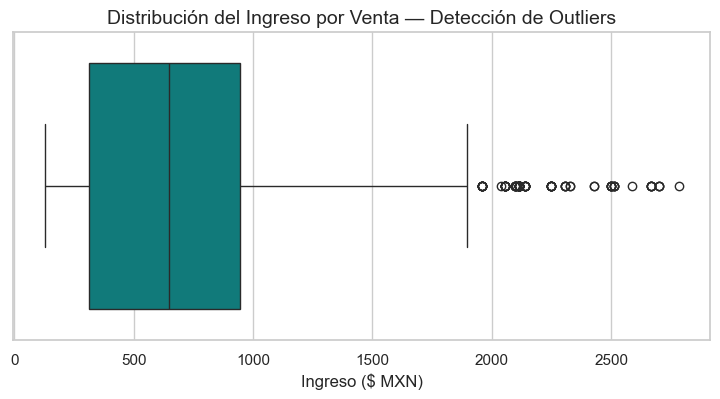

In [71]:
# 4.4 Gráfico de Caja (Boxplot) — visualiza los outliers calculados arriba
plt.figure(figsize=(9, 4))
sns.boxplot(x=ventas_validas["total"], color="darkcyan")
plt.title("Distribución del Ingreso por Venta — Detección de Outliers", fontsize=14)
plt.xlabel("Ingreso ($ MXN)")
plt.show()

### Interpretación: Gráfico de Caja (Outliers)
* **Qué se observa:** el cuerpo central de la caja (RIC) va de 312.51 a 947.07 MXN, con la mediana en 663.46. Los puntos a la derecha del bigote superior son **99 transacciones (2.74% del total)** que superan los 1,898.91 MXN, llegando hasta 2,781.98 MXN.
* **Qué significa:** existe un grupo pequeño pero real de compras de alto valor que se separa claramente del comportamiento típico del resto de las transacciones.
* **Qué posible causa lo explica:** al comercializar artesanías, es normal que coexistan piezas de bajo costo y alta rotación (llaveros, aretes) con piezas únicas o muy elaboradas (bordados complejos, huipiles) que generan tickets atípicamente altos.
* **Qué decisión podría tomarse:** no eliminar estos outliers del dataset, ya que corresponden a ventas reales y de alto valor; en cambio, se pueden usar para identificar y promover activamente el catálogo de "piezas premium" como una línea de negocio diferenciada.

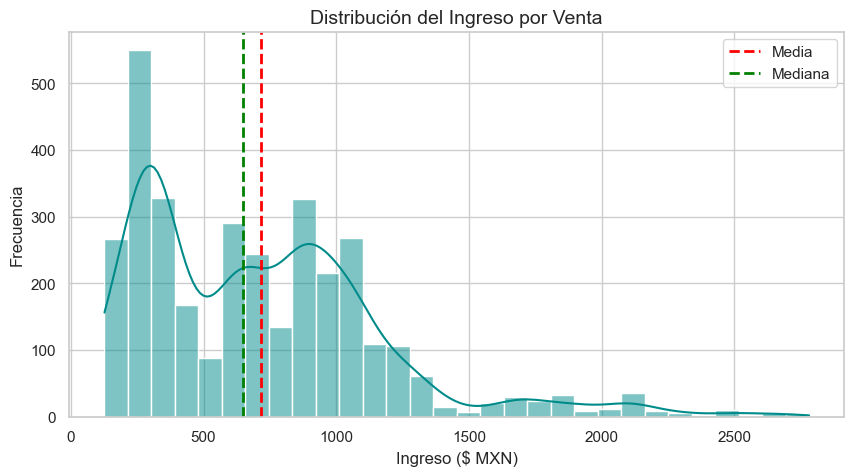

In [72]:
# 4.5 Distribución del Ingreso (Histograma)
plt.figure(figsize=(10, 5))
sns.histplot(ventas_validas["total"], bins=30, kde=True, color="darkcyan")
plt.title("Distribución del Ingreso por Venta", fontsize=14)
plt.xlabel("Ingreso ($ MXN)")
plt.ylabel("Frecuencia")
plt.axvline(ventas_validas["total"].mean(), color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(ventas_validas["total"].median(), color='green', linestyle='dashed', linewidth=2, label='Mediana')
plt.legend()
plt.show()

### Interpretación: Distribución de Ingresos
* **Qué se observa:** una distribución asimétrica positiva (sesgada a la derecha), con la mayor concentración de compras entre 300 y 900 MXN.
* **Qué significa:** la mayoría de los clientes de IKAL realiza compras estándar de costo bajo/medio; un grupo reducido de compras de mayor valor "jala" la media por encima de la mediana.
* **Qué posible causa lo explica:** la diferencia de precios en el catálogo — accesorios de bajo costo se venden en alto volumen, mientras que prendas complejas se venden menos veces pero a precio elevado.
* **Qué decisión podría tomarse:** diseñar estrategias de *up-selling* (ej. "agrega un accesorio por $150 más") para desplazar la mediana de gasto general hacia arriba.

## 5. Análisis Bivariado
Relación entre dos variables de negocio para entender qué canales y métodos de pago rinden mejor. Se usa `ventas_validas` (sin cancelados) para que los indicadores financieros reflejen ingresos reales.

In [73]:
# 1. Ingresos y transacciones por canal
ticket_canal = ventas_validas.groupby("canal").agg(
    Transacciones=("venta_id", "count"),
    Ingresos_Totales=("total", "sum"),
    Ticket_Promedio=("total", "mean")
).sort_values(by="Ingresos_Totales", ascending=False)
display(ticket_canal.round(2))

,Transacciones,Ingresos_Totales,Ticket_Promedio
canal,,,
Web,1374,"975,829.62",710.21
Instagram,965,"675,565.45",700.07
Facebook,689,"513,019.25",744.59
WhatsApp,345,"247,533.51",717.49


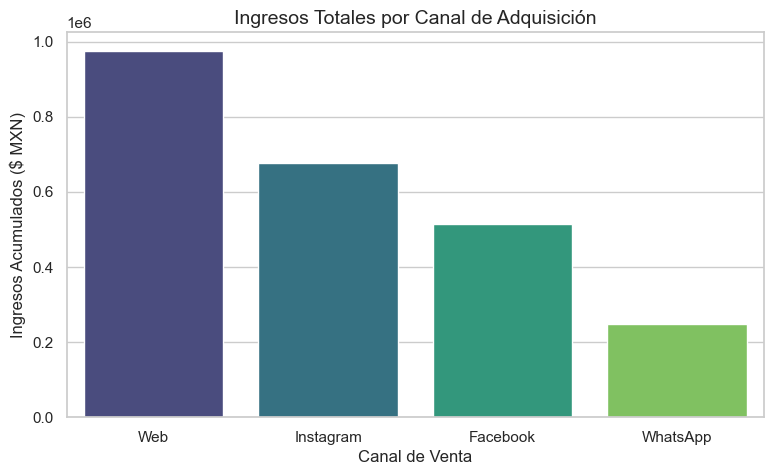

In [74]:
# Gráfico de barras: Ingresos por Canal
plt.figure(figsize=(9, 5))
sns.barplot(x=ticket_canal.index, y=ticket_canal["Ingresos_Totales"], hue=ticket_canal.index,
            palette="viridis", legend=False)
plt.title("Ingresos Totales por Canal de Adquisición", fontsize=14)
plt.xlabel("Canal de Venta")
plt.ylabel("Ingresos Acumulados ($ MXN)")
plt.show()

In [75]:
# 2. Desempeño por método de pago
metodo_pago = ventas_validas.groupby("metodo_pago").agg(
    Frecuencia=("venta_id", "count"),
    Ingresos_Totales=("total", "sum"),
    Ticket_Promedio=("total", "mean")
)
display(metodo_pago.round(2))

,Frecuencia,Ingresos_Totales,Ticket_Promedio
metodo_pago,,,
Crédito,1675,"1,176,578.24",702.43
Débito,1698,"1,235,369.59",727.54


### Interpretación: Ingresos por Canal
* **Qué se observa:** el canal Web lidera con **$975,830 MXN (40.5% del ingreso válido)** y 1,374 transacciones, seguido por Instagram. WhatsApp genera el menor ingreso total, pero mantiene un ticket promedio competitivo.
* **Qué significa:** la tienda web oficial es el canal más fuerte, pero **no concentra la mayoría del ingreso**: el 59.5% restante se reparte entre los tres canales de redes sociales, por lo que el negocio depende de un mix de canales y no solo de la web.
* **Qué posible causa lo explica:** la plataforma Web permite pasarelas de pago automatizadas 24/7 y compras sin intervención manual, mientras que WhatsApp requiere atención personalizada, lo que limita su volumen pero puede favorecer tickets de mayor confianza.
* **Qué decisión podría tomarse:** fortalecer la inversión en Web sin descuidar Instagram (segundo lugar en ingresos), y usar WhatsApp como canal de atención personalizada o cierre de ventas de alto valor más que como canal masivo.

### Interpretación: Método de Pago
* **Qué se observa:** la distribución entre Crédito y Débito muestra volúmenes de transacciones e ingresos similares entre ambos métodos, sin una diferencia dominante marcada.
* **Qué significa:** los clientes de IKAL no muestran una preferencia extrema por un método de pago sobre otro, lo que sugiere que ambos deben mantenerse habilitados y no representan una barrera de conversión.
* **Qué posible causa lo explica:** ambos métodos están igualmente integrados en la pasarela de pagos de la plataforma, sin fricción adicional para ninguno de los dos.
* **Qué decisión podría tomarse:** mantener ambas opciones de pago activas en todos los canales; no se justifica, con esta evidencia, invertir en agregar métodos de pago adicionales como prioridad inmediata.

## 6. Análisis Multivariado
Cruce de más de dos variables para obtener hallazgos segmentados (año, canal y tipo de producto). Se usa 2025 como año representativo porque es el **único año completo** en el dataset (2023 y 2026 están incompletos, ver sección 3).

tipo_producto         Artesano  Marca IKAL
año_venta canal                           
2023      Facebook        0.00   12,624.85
          Instagram       0.00    7,369.16
          Web             0.00   31,277.49
          WhatsApp        0.00    7,037.43
2024      Facebook   81,974.41   36,238.06
          Instagram 113,513.78   58,146.10
          Web       130,970.44  101,187.01
          WhatsApp   41,154.24   20,048.00
2025      Facebook  154,189.82   83,659.05
          Instagram 206,090.65  112,063.46
          Web       320,230.49  142,640.17
          WhatsApp   78,300.84   43,856.04
2026      Facebook   93,068.23   51,264.83
          Instagram 124,188.49   54,193.81
          Web       163,443.32   86,080.70
          WhatsApp   36,252.45   20,884.51

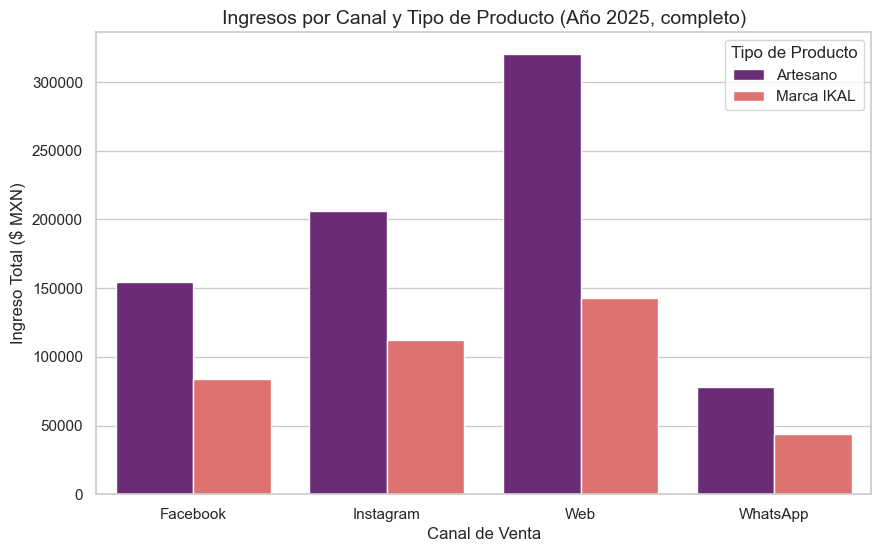

In [76]:
# Cruce: Ingresos por Año, Canal y Tipo de Producto (ventas válidas)
multivariado = ventas_validas.groupby(["año_venta", "canal", "tipo_producto"])["total"].sum().unstack(fill_value=0)
display(multivariado.round(2))

# Gráfico de Barras Agrupadas para 2025 (único año completo del dataset)
ventas_2025 = ventas_validas[ventas_validas["año_venta"] == 2025]
ingresos_multi = ventas_2025.groupby(["canal", "tipo_producto"])["total"].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=ingresos_multi, x="canal", y="total", hue="tipo_producto", palette="magma")
plt.title("Ingresos por Canal y Tipo de Producto (Año 2025, completo)", fontsize=14)
plt.xlabel("Canal de Venta")
plt.ylabel("Ingreso Total ($ MXN)")
plt.legend(title="Tipo de Producto")
plt.show()

### Interpretación: Comportamiento Multivariado
* **Qué se observa:** en los cuatro canales, la categoría `Artesano` genera más ingresos que `Marca IKAL`, con la brecha más amplia en el canal Web.
* **Qué significa:** el modelo de negocio central de la plataforma está funcionando: los clientes prefieren comprar piezas etiquetadas bajo la identidad del artesano en lugar de la marca paraguas.
* **Qué posible causa lo explica:** la tendencia de consumo consciente ("fair trade"), donde los compradores buscan autenticidad y prefieren apoyar directamente al creador conociendo el impacto social de su compra.
* **Qué decisión podría tomarse:** reforzar el *storytelling* en redes sociales sobre las historias de los artesanos, ya que esta categoría es la principal generadora de valor en todos los canales.

## 7. Análisis Temporal
Evaluación de tendencias a lo largo de los meses, comparación entre años y hábitos de compra según el día de la semana.

**Aclaración sobre alcance:** el dataset **no incluye la hora exacta de cada venta** (solo la fecha), por lo que **no es posible calcular "horas de mayor demanda"**; y **no existe una tabla o bandera de promociones**, por lo que tampoco es posible analizar "variaciones antes/después de promociones". Ambos puntos se dejan documentados aquí en vez de omitirse en silencio, como una limitación de los datos disponibles y una recomendación para futuras capturas de datos (registrar timestamp completo y eventos promocionales).

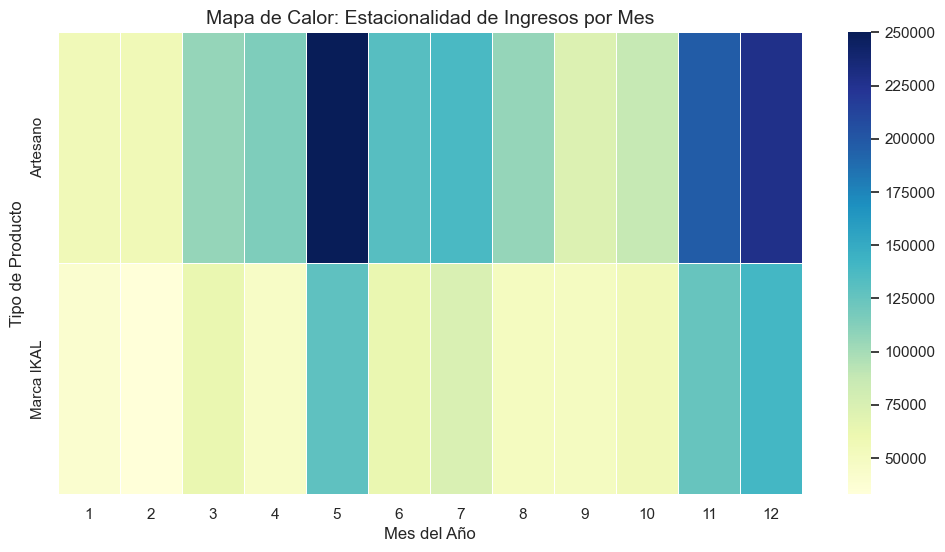

In [77]:
# 1. Mapa de Calor (Heatmap): Estacionalidad por Mes y Tipo de Producto
matriz_temporal = ventas_validas.groupby(["mes", "tipo_producto"])["total"].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(matriz_temporal.T, cmap="YlGnBu", annot=False, fmt=".0f", linewidths=.5)
plt.title("Mapa de Calor: Estacionalidad de Ingresos por Mes", fontsize=14)
plt.xlabel("Mes del Año")
plt.ylabel("Tipo de Producto")
plt.show()

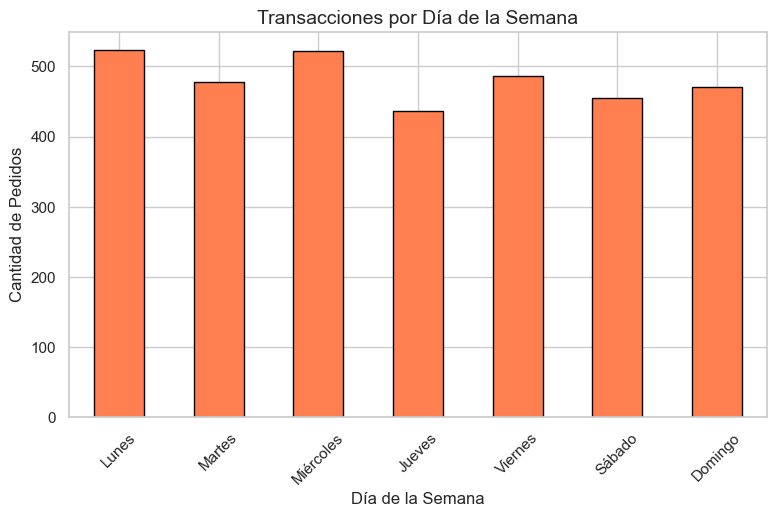

Día con MÁS transacciones: Lunes (523)
Día con MENOS transacciones: Jueves (437)


In [78]:
# 2. Ventas por Día de la Semana (ordenado Lunes -> Domingo, no alfabéticamente)
dia_semana_ventas = ventas_validas.groupby("dia_semana_es", observed=True)["venta_id"].count()

plt.figure(figsize=(9, 5))
dia_semana_ventas.plot(kind="bar", color="coral", edgecolor="black")
plt.title("Transacciones por Día de la Semana", fontsize=14)
plt.xlabel("Día de la Semana")
plt.ylabel("Cantidad de Pedidos")
plt.xticks(rotation=45)
plt.show()

print("Día con MÁS transacciones:", dia_semana_ventas.idxmax(), f"({dia_semana_ventas.max()})")
print("Día con MENOS transacciones:", dia_semana_ventas.idxmin(), f"({dia_semana_ventas.min()})")

,Transacciones,Ingresos_Totales,Meses_con_datos,Ingreso_promedio_mensual
año_venta,,,,
2023,61,"58,308.93",5,"11,661.79"
2024,813,"583,232.04",12,"48,602.67"
2025,1548,"1,141,030.52",12,"95,085.88"
2026,951,"629,376.34",8,"78,672.04"


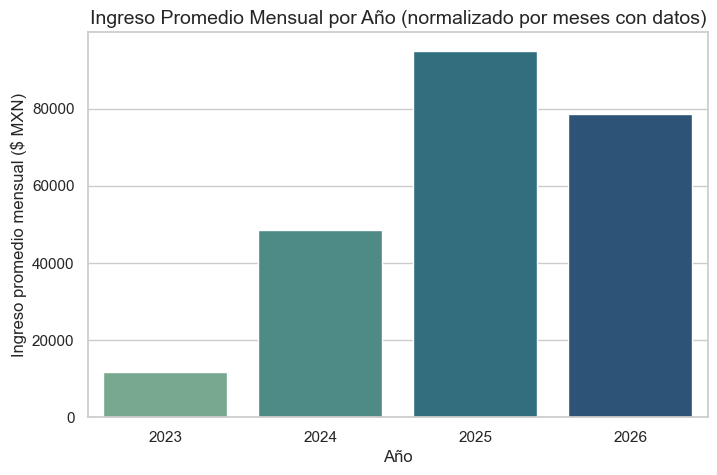

In [79]:
# 3. Comparación entre años — normalizada por meses cubiertos (2023 y 2026 son años parciales)
meses_cubiertos = ventas_validas.groupby("año_venta")["mes"].nunique()
resumen_anual = ventas_validas.groupby("año_venta").agg(
    Transacciones=("venta_id", "count"),
    Ingresos_Totales=("total", "sum")
)
resumen_anual["Meses_con_datos"] = meses_cubiertos
resumen_anual["Ingreso_promedio_mensual"] = (resumen_anual["Ingresos_Totales"] / resumen_anual["Meses_con_datos"]).round(2)
display(resumen_anual.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(x=resumen_anual.index.astype(str), y=resumen_anual["Ingreso_promedio_mensual"],
            hue=resumen_anual.index.astype(str), palette="crest", legend=False)
plt.title("Ingreso Promedio Mensual por Año (normalizado por meses con datos)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Ingreso promedio mensual ($ MXN)")
plt.show()

### Interpretación: Tendencia Temporal y Estacionalidad

* **Qué se observa (estacionalidad):** en el heatmap hay picos claros de ingresos en el mes 5 (mayo) y en los meses 11-12 (noviembre-diciembre).
* **Qué se observa (día de la semana):** ordenando correctamente de lunes a domingo, **Lunes (523) y Miércoles (522) son los días con más transacciones**, mientras que **Jueves (437) es el día con menos actividad**, y el fin de semana se mantiene en niveles intermedios-bajos.
* **Qué se observa (comparación entre años, normalizada):** el ingreso promedio mensual crece de forma sostenida: ~$11,662 (2023, parcial) → ~$48,603 (2024) → ~$95,086 (2025, año completo) → ~$78,672 (2026, parcial a agosto). Al normalizar por meses cubiertos se evita la lectura errónea de que el negocio "cayó" en 2026 — en realidad 2026 solo lleva 8 meses de datos y su promedio mensual sigue por encima de 2024.
* **Qué significa:** el negocio está impulsado por festividades estacionales (no por una tendencia plana), muestra una fase de crecimiento año con año, y el comportamiento semanal no favorece al fin de semana como podría asumirse en retail físico.
* **Qué posible causa lo explica:** mayo coincide con el Día de las Madres y noviembre-diciembre con el Buen Fin, Navidad y aguinaldos. Los picos de miércoles y lunes sugieren compras planeadas entre semana (posiblemente desde el trabajo/oficina), mientras que jueves podría coincidir con menor actividad promocional o de tráfico — esto último es una hipótesis a validar con datos de marketing, no una conclusión definitiva.
* **Qué decisión podría tomarse:**
  - **Logística:** adelantar producción artesanal ~3 meses antes de mayo y noviembre para asegurar stock.
  - **Marketing:** concentrar campañas y newsletters.
  - **Planeación financiera:** usar el ingreso promedio mensual (no el total anual crudo) al proyectar 2026, dado que el año aún no cierra.

## 8. Análisis Geoespacial: Mapa de Calor de Puntos de Venta

Para visualizar el impacto comercial de **IKAL "Alma Artesanal"** en el territorio nacional y específicamente en la región productora (Xicotepec, Pantepec, Puebla), se genera un mapa de calor geográfico interactivo, usando `ventas_validas` para que el peso de cada ciudad refleje ingresos reales (sin pedidos cancelados).

In [80]:
# 1. Coordenadas de los puntos de venta
coordenadas = {
    'CDMX': [19.4326, -99.1332],
    'Toluca': [19.2826, -99.6557],
    'Puebla': [19.0414, -98.2063],
    'Xicotepec de Juárez': [20.2747, -97.9548],
    'Monterrey': [25.6866, -100.3161],
    'Querétaro': [20.5881, -100.3899],
    'Pantepec': [20.4851, -97.9348],
    'Guadalajara': [20.6597, -103.3500]
}

# Verificación: ¿todas las ubicaciones del dataset tienen coordenadas asignadas?
ubicaciones_sin_coordenadas = set(ventas_validas['ubicacion_comprador'].unique()) - set(coordenadas.keys())
print("Ubicaciones sin coordenadas asignadas:", ubicaciones_sin_coordenadas if ubicaciones_sin_coordenadas else "Ninguna ✔")

# 2. Ingresos totales por ubicación (ventas válidas)
ventas_mapa = ventas_validas.groupby('ubicacion_comprador')['total'].sum().reset_index()
ventas_mapa['Latitud'] = ventas_mapa['ubicacion_comprador'].map(lambda x: coordenadas[x][0])
ventas_mapa['Longitud'] = ventas_mapa['ubicacion_comprador'].map(lambda x: coordenadas[x][1])

# 3. Mapa de calor
mapa_ikal = folium.Map(location=[21.0, -100.0], zoom_start=6, tiles='CartoDB dark_matter')
datos_calor = ventas_mapa[['Latitud', 'Longitud', 'total']].values.tolist()
HeatMap(datos_calor, radius=25, blur=15, max_zoom=1).add_to(mapa_ikal)
mapa_ikal

Ubicaciones sin coordenadas asignadas: Ninguna ✔


![Mapa de Calor ](img/Mapa.png)

**Interpretación del Mapa Geoespacial:**
1. **Qué se observa:** zonas de calor (hotspots) sobre el mapa de México; las áreas más intensas indican los puntos de venta con mayor concentración de ingresos.
2. **Qué significa:** permite ver la huella de mercado del negocio a nivel nacional.
3. **Posible causa:** las grandes urbes concentran mayor volumen monetario por densidad poblacional, mientras que la zona de origen (Sierra Norte de Puebla) mantiene presencia relevante por el conocimiento local de la marca.
4. **Decisión sugerida:** usar esta distribución geográfica para planificar rutas logísticas de envío consolidado y evaluar en qué ciudades estratégicas valdría la pena reforzar publicidad local.

**Mapa de Burbujas: Volumen de Ingresos por Ciudad**

Complementa la vista de calor con un mapa de burbujas donde el tamaño es proporcional al ingreso exacto por ciudad.

In [81]:
mapa_burbujas = folium.Map(location=[21.0, -100.0], zoom_start=6, tiles='CartoDB positron')

for _, row in ventas_mapa.iterrows():
    radio_burbuja = row['total'] / 25000
    texto_popup = f"<b>{row['ubicacion_comprador']}</b><br>Ingresos: ${row['total']:,.2f} MXN"
    folium.CircleMarker(
        location=[row['Latitud'], row['Longitud']],
        radius=radio_burbuja,
        popup=folium.Popup(texto_popup, max_width=300),
        color='#264653',
        fill=True,
        fill_color='#2a9d8f',
        fill_opacity=0.7,
        tooltip=f"Ver ventas de {row['ubicacion_comprador']}"
    ).add_to(mapa_burbujas)

mapa_burbujas

![Mapa de Burbujas](img/Mapa1.png)

**Interpretación del Mapa de Burbujas:**
1. **Qué se observa:** círculos sobre el mapa nacional cuyo radio es proporcional al volumen de ingresos de cada ciudad; al interactuar se despliega el monto exacto.
2. **Qué significa:** permite comparar visualmente el tamaño de mercado de cada punto de venta de IKAL.
3. **Posible causa:** mercados con mayor población y penetración de e-commerce (como CDMX y Monterrey) tienden a mostrar burbujas más grandes.
4. **Decisión sugerida:** asignar presupuesto de logística y publicidad de forma proporcional al tamaño de mercado observado, priorizando retención en las ciudades de mayor ingreso.

<h3>Conclusión</h3>

En conclusión, tras revisar a fondo la información de IKAL Alma Artesanal, comprobamos que los datos son muy confiables y nos muestran una visión real de los ingresos una vez que descartamos los pedidos cancelados. Descubrimos que, aunque la página web es nuestro canal de ventas más fuerte, el negocio realmente se sostiene gracias a un equilibrio saludable con nuestras redes sociales (Instagram, Facebook y WhatsApp), por lo que no dependemos de un solo medio. Además, las ventas muestran un crecimiento mensual constante desde 2023 y picos muy claros de demanda durante el Día de las Madres y el fin de año, siendo curiosamente los lunes y miércoles los días con más compras, un dato excelente para saber exactamente cuándo lanzar nuestras campañas de publicidad. Por otro lado, confirmamos que los clientes prefieren comprar los productos que resaltan directamente la identidad del artesano por encima de la marca general IKAL, lo que nos demuestra que el enfoque social y auténtico del proyecto está funcionando a la perfección. Finalmente, notamos que existen compras poco frecuentes pero de un valor bastante alto (llegando a casi los 2,800 pesos); en lugar de verlas como anomalías, representan una gran oportunidad comercial para crear y promocionar una línea exclusiva de piezas "premium".
